# Equilibrium LOB for a Polymarket Digital Option
## Unified Trader MFG with Ma-Noh Dynamics

**Input**: Mid-price $p$, fee $f$, valuation distribution $F = \text{Beta}(\alpha_F, \beta_F)$, discount rate distribution $G = \text{Uniform}[r_{\min}, r_{\max}]$.

**Output**: Ask-side density $d(a)$, cumulative depth $\mathcal{D}(a) = \int_a^{a_{\max}} d(s)\,ds$, bid side, spread.

---
# Part I: Model

## §1. Contract and One-Sided Book
Binary option: $\text{Payoff}_{YES} = \mathbf{1}\{S_T \ge K\}$, $\text{Payoff}_{NO} = 1 - \text{Payoff}_{YES}$. One price $p \in (0,1)$. Selling YES at $a$ = buying NO at $1-a$. **The YES ask book suffices.**

## §2. Unified Trader Population
Each trader has $(v, r)$: valuation $v \sim \text{Beta}(\alpha_F, \beta_F)$, discount rate $r \sim \text{Uniform}[r_{\min}, r_{\max}]$.
- $v \ge a_{\text{best}}$: **market buyer** (consumes ask depth)
- $v \le b_{\text{best}}$: **market seller** (consumes bid depth)
- $b < v < a$: **LP** (posts limit orders)

## §3. Ask-Side Structure
- **Market order flow**: $\phi(a) = \lambda[1 - F(a)]$ (buyers with $v \ge a$)
- **Ask-side LPs**: traders with $v < p$ who post limit sells at $a > p$
- **LP margin** (after fee $f$): $(a(1-f) - v) \cdot \delta$
- **No-arbitrage**: $a \ge p$ (can't sell below fundamental)

## §4. LP Depth Dynamics (Ma-Noh)
At ask $a$, depth $q \in \{0, \delta, 2\delta, \ldots\}$:
- Up: $q \to q + \delta_s$ at rate $l \cdot \Psi(u)$, cost $(\kappa/2)l^2$
- Down: $q \to (q-\delta_b)^+$ at rate $\mu(a) \cdot \Theta(u)$, profit $(a(1-f)-v)\delta_b$

where $\mu(a) = \phi(a)/\mathcal{D}(a)$, $\Psi(u) = 1+\psi u$, $\Theta(u) = 1+\theta(1-u)$.

## §5. HJB
$$rV_i = \max_{l \ge 0}\left\{(a(1\!-\!f)\!-\!v)\delta_b \lambda_b^i \mathbb{1}_{q_i>0} - \frac{\kappa}{2}l^2 + l\Psi_i(V_{j^+}\!-\!V_i) + \lambda_b^i(V_{j^-}\!-\!V_i)\right\}$$
Optimal: $l_i^* = \Pi_{[0,\bar{l}]}\!\left(\frac{\Psi_i}{\kappa}(V_{j^+}-V_i)\right)$. Matrix invertible without pinning ($r > 0$ gives strict diagonal dominance).

## §6. Bertrand + Equilibrium
$a^*(v, r) = \arg\max_a V_0(v, r, a, \mu(a))$. Fixed point: $\mathcal{D} \to \mu \to \text{Ma-Noh} \to \text{Bertrand} \to \mathcal{D}$.

Density $d(a)$ integrated to get cumulative: $\mathcal{D}_{\text{cum}}(a) = \int_a^{a_{\max}} d(s)\,ds$.

Bid side: reflect ask through $p$: $d_{\text{bid}}(p-x) = d_{\text{ask}}(p+x)$. Spread: $s = a_{\text{best}} - b_{\text{best}} = 2(a_{\text{best}} - p)$.

---
# Part II: Implementation

In [1]:
import numpy as np
from scipy.stats import beta as beta_dist
import matplotlib.pyplot as plt
import time

plt.rcParams.update({
    'figure.figsize': (10, 6), 'font.size': 12, 'axes.labelsize': 14,
    'axes.titlesize': 14, 'legend.fontsize': 11, 'lines.linewidth': 2,
    'figure.dpi': 120,
})

## §7. Ma-Noh Functions

In [2]:
def proj_0_lbar(x, lbar):
    return np.minimum(np.maximum(x, 0.0), lbar)

def rank_grid(N):
    return (np.arange(1, N+1) - 0.5) / N

def destination_indices(q, delta_s, delta_b):
    q = np.asarray(q); N = q.size
    jp = np.empty(N, dtype=int); jm = np.empty(N, dtype=int)
    for i in range(N):
        jp[i] = int(np.argmin(np.abs(q - (q[i] + delta_s))))
        jm[i] = int(np.argmin(np.abs(q - max(q[i] - delta_b, 0.0))))
    return jp, jm

def solve_hjb(q, u, jp, jm, rho, kappa, l_bar, psi, theta, margin, delta_b,
              mu_exec, max_iter=60, tol=1e-10):
    N=len(q); Psi=1+psi*u; Theta=1+theta*(1-u)
    l=np.zeros(N); V=np.zeros(N)
    for it in range(max_iter):
        ls=l*Psi; lb=mu_exec*Theta
        pi=margin*lb*delta_b*(q>0).astype(float)
        A=np.zeros((N,N)); b=np.zeros(N)
        for i in range(N):
            A[i,i]=rho+ls[i]+lb[i]; A[i,jp[i]]-=ls[i]; A[i,jm[i]]-=lb[i]
            b[i]=pi[i]-0.5*kappa*l[i]**2
        try: Vn=np.linalg.solve(A,b)
        except: break
        ln=proj_0_lbar((Psi/kappa)*(Vn[jp]-Vn), l_bar)
        if np.max(np.abs(ln-l))<tol: V,l=Vn,ln; break
        V,l=Vn,ln
    return V, l

def stat_dist(jp, jm, lp, lm):
    N=len(lp); rates=np.array(lp)+np.array(lm)
    bL=max(np.max(rates),1e-12); P=np.zeros((N,N))
    for i in range(N):
        if rates[i]>0:
            P[i,jp[i]]+=lp[i]/bL; P[i,jm[i]]+=lm[i]/bL; P[i,i]+=1-rates[i]/bL
        else: P[i,i]=1
    m=np.ones(N)/N; PT=P.T
    for _ in range(80000):
        mn=PT@m; s=mn.sum()
        if s<=0: break
        mn/=s
        if np.max(np.abs(mn-m))<1e-14: m=mn; break
        m=mn
    return m

def quant_upd(u,q,m):
    M=np.cumsum(m); M=np.clip(M,0,1); Me=M.copy()
    for i in range(1,len(Me)):
        if Me[i]<=Me[i-1]: Me[i]=Me[i-1]+1e-12
    return np.interp(u,np.clip(Me,0,1),q,left=q[0],right=q[-1])

print('Ma-Noh functions loaded.')

Ma-Noh functions loaded.


## §8. Parameters

In [3]:
p_mid = 0.65; fee = 0.02
alpha_F = 6.5; beta_F = 3.5  # Beta mean = 0.65 = p_mid
lam_arr = 10.0
delta_s=1.0; delta_b=1.0; kappa=0.4; l_bar=3.0; psi=0.3; theta=0.7
N_total=100.0; r_min=0.05; r_max=2.0

N_v=5; N_r=6; N_a=12; N_q=35; q_max=20.0
v_grid = np.linspace(0.05, p_mid*(1-fee)-0.01, N_v)
r_grid = np.linspace(r_min, r_max, N_r)
a_grid = np.linspace(p_mid+0.005, min(0.98,1-fee), N_a)
omega=0.10; outer_max=30; cesaro_start=18; sigma_smooth=0.020

def phi_flow(a): return lam_arr*(1-beta_dist.cdf(a, alpha_F, beta_F))
def lp_margin(a, v): return a*(1-fee)-v

def solve_at_price(a_p, v_lp, rho, mu, Nq=N_q, qm=q_max, ni=5, wi=0.15):
    mg=lp_margin(a_p, v_lp)
    if mg<=0.001: return 0.0, 0.0
    u=rank_grid(Nq); q=np.linspace(0,qm,Nq)
    for _ in range(ni):
        jp,jm=destination_indices(q,delta_s,delta_b)
        V,l=solve_hjb(q,u,jp,jm,rho=rho,kappa=kappa,l_bar=l_bar,
                       psi=psi,theta=theta,margin=mg,delta_b=delta_b,mu_exec=mu)
        Psi=1+psi*u; Theta=1+theta*(1-u)
        m=stat_dist(jp,jm,l*Psi,mu*np.ones_like(q)*Theta)
        qt=quant_upd(u,q,m)
        q=np.maximum(np.sort((1-wi)*q+wi*qt),0)
    return float(V[0]), float(np.dot(m,q))

print(f'p={p_mid}, f={fee}, Beta({alpha_F},{beta_F})')
print(f'Ask grid: [{a_grid[0]:.3f}, {a_grid[-1]:.3f}], LP v: [{v_grid[0]:.3f}, {v_grid[-1]:.3f}]')

p=0.65, f=0.02, Beta(6.5,3.5)
Ask grid: [0.655, 0.980], LP v: [0.050, 0.627]


## §9. Equilibrium

In [4]:
D_a=np.ones(N_a)*2.0; D_ces=np.zeros(N_a); ces_n=0
dv=v_grid[1]-v_grid[0] if N_v>1 else 1; dr=r_grid[1]-r_grid[0] if N_r>1 else 1
t0=time.time(); a_star_2d=np.zeros((N_v,N_r)); d_bar_2d=np.zeros((N_v,N_r))

for oit in range(outer_max):
    mu_a=phi_flow(a_grid)/np.maximum(D_a,0.01)
    for kv in range(N_v):
        for kr in range(N_r):
            best=-np.inf; bj=0; bdb=0
            for j in range(N_a):
                if lp_margin(a_grid[j],v_grid[kv])<=0.001: continue
                V0j,dbj=solve_at_price(a_grid[j],v_grid[kv],r_grid[kr],mu_a[j],
                                        ni=3 if oit<10 else 5)
                if V0j>best: best=V0j; bj=j; bdb=dbj
            a_star_2d[kv,kr]=a_grid[bj]; d_bar_2d[kv,kr]=bdb
    D_new=np.zeros(N_a); step=a_grid[1]-a_grid[0]
    for kv in range(N_v):
        for kr in range(N_r):
            fv=beta_dist.pdf(v_grid[kv],alpha_F,beta_F)
            w=N_total*fv*dv/(r_max-r_min)*dr*d_bar_2d[kv,kr]
            kern=np.exp(-0.5*((a_grid-a_star_2d[kv,kr])/sigma_smooth)**2)
            kern/=(np.sum(kern)*step+1e-20)
            D_new+=w*kern*step
    D_new=np.maximum(D_new,0.005)
    D_a=(1-omega)*D_a+omega*D_new
    if oit>=cesaro_start: ces_n+=1; D_ces+=(D_a-D_ces)/ces_n
    if (oit+1)%5==0 or oit==0:
        mid=N_v//2
        print(f'iter {oit+1:3d}: a* in [{a_star_2d[mid,:].min():.3f},{a_star_2d[mid,:].max():.3f}], '
              f'D_max={D_a.max():.2f} [{time.time()-t0:.0f}s]')

D_final=D_ces if ces_n>0 else D_a
mu_final=phi_flow(a_grid)/np.maximum(D_final,0.005)
print(f'\nDone in {time.time()-t0:.0f}s')

iter   1: a* in [0.714,0.803], D_max=2.50 [3s]
iter   5: a* in [0.685,0.773], D_max=3.20 [14s]
iter  10: a* in [0.685,0.773], D_max=3.45 [28s]
iter  15: a* in [0.655,0.773], D_max=3.72 [50s]
iter  20: a* in [0.655,0.773], D_max=3.71 [72s]
iter  25: a* in [0.655,0.744], D_max=3.69 [94s]
iter  30: a* in [0.655,0.773], D_max=4.13 [116s]

Done in 116s


---
# Part III: Results
## §10. LOB Shape

Best ask=0.655, Best bid=0.645, Spread=0.010


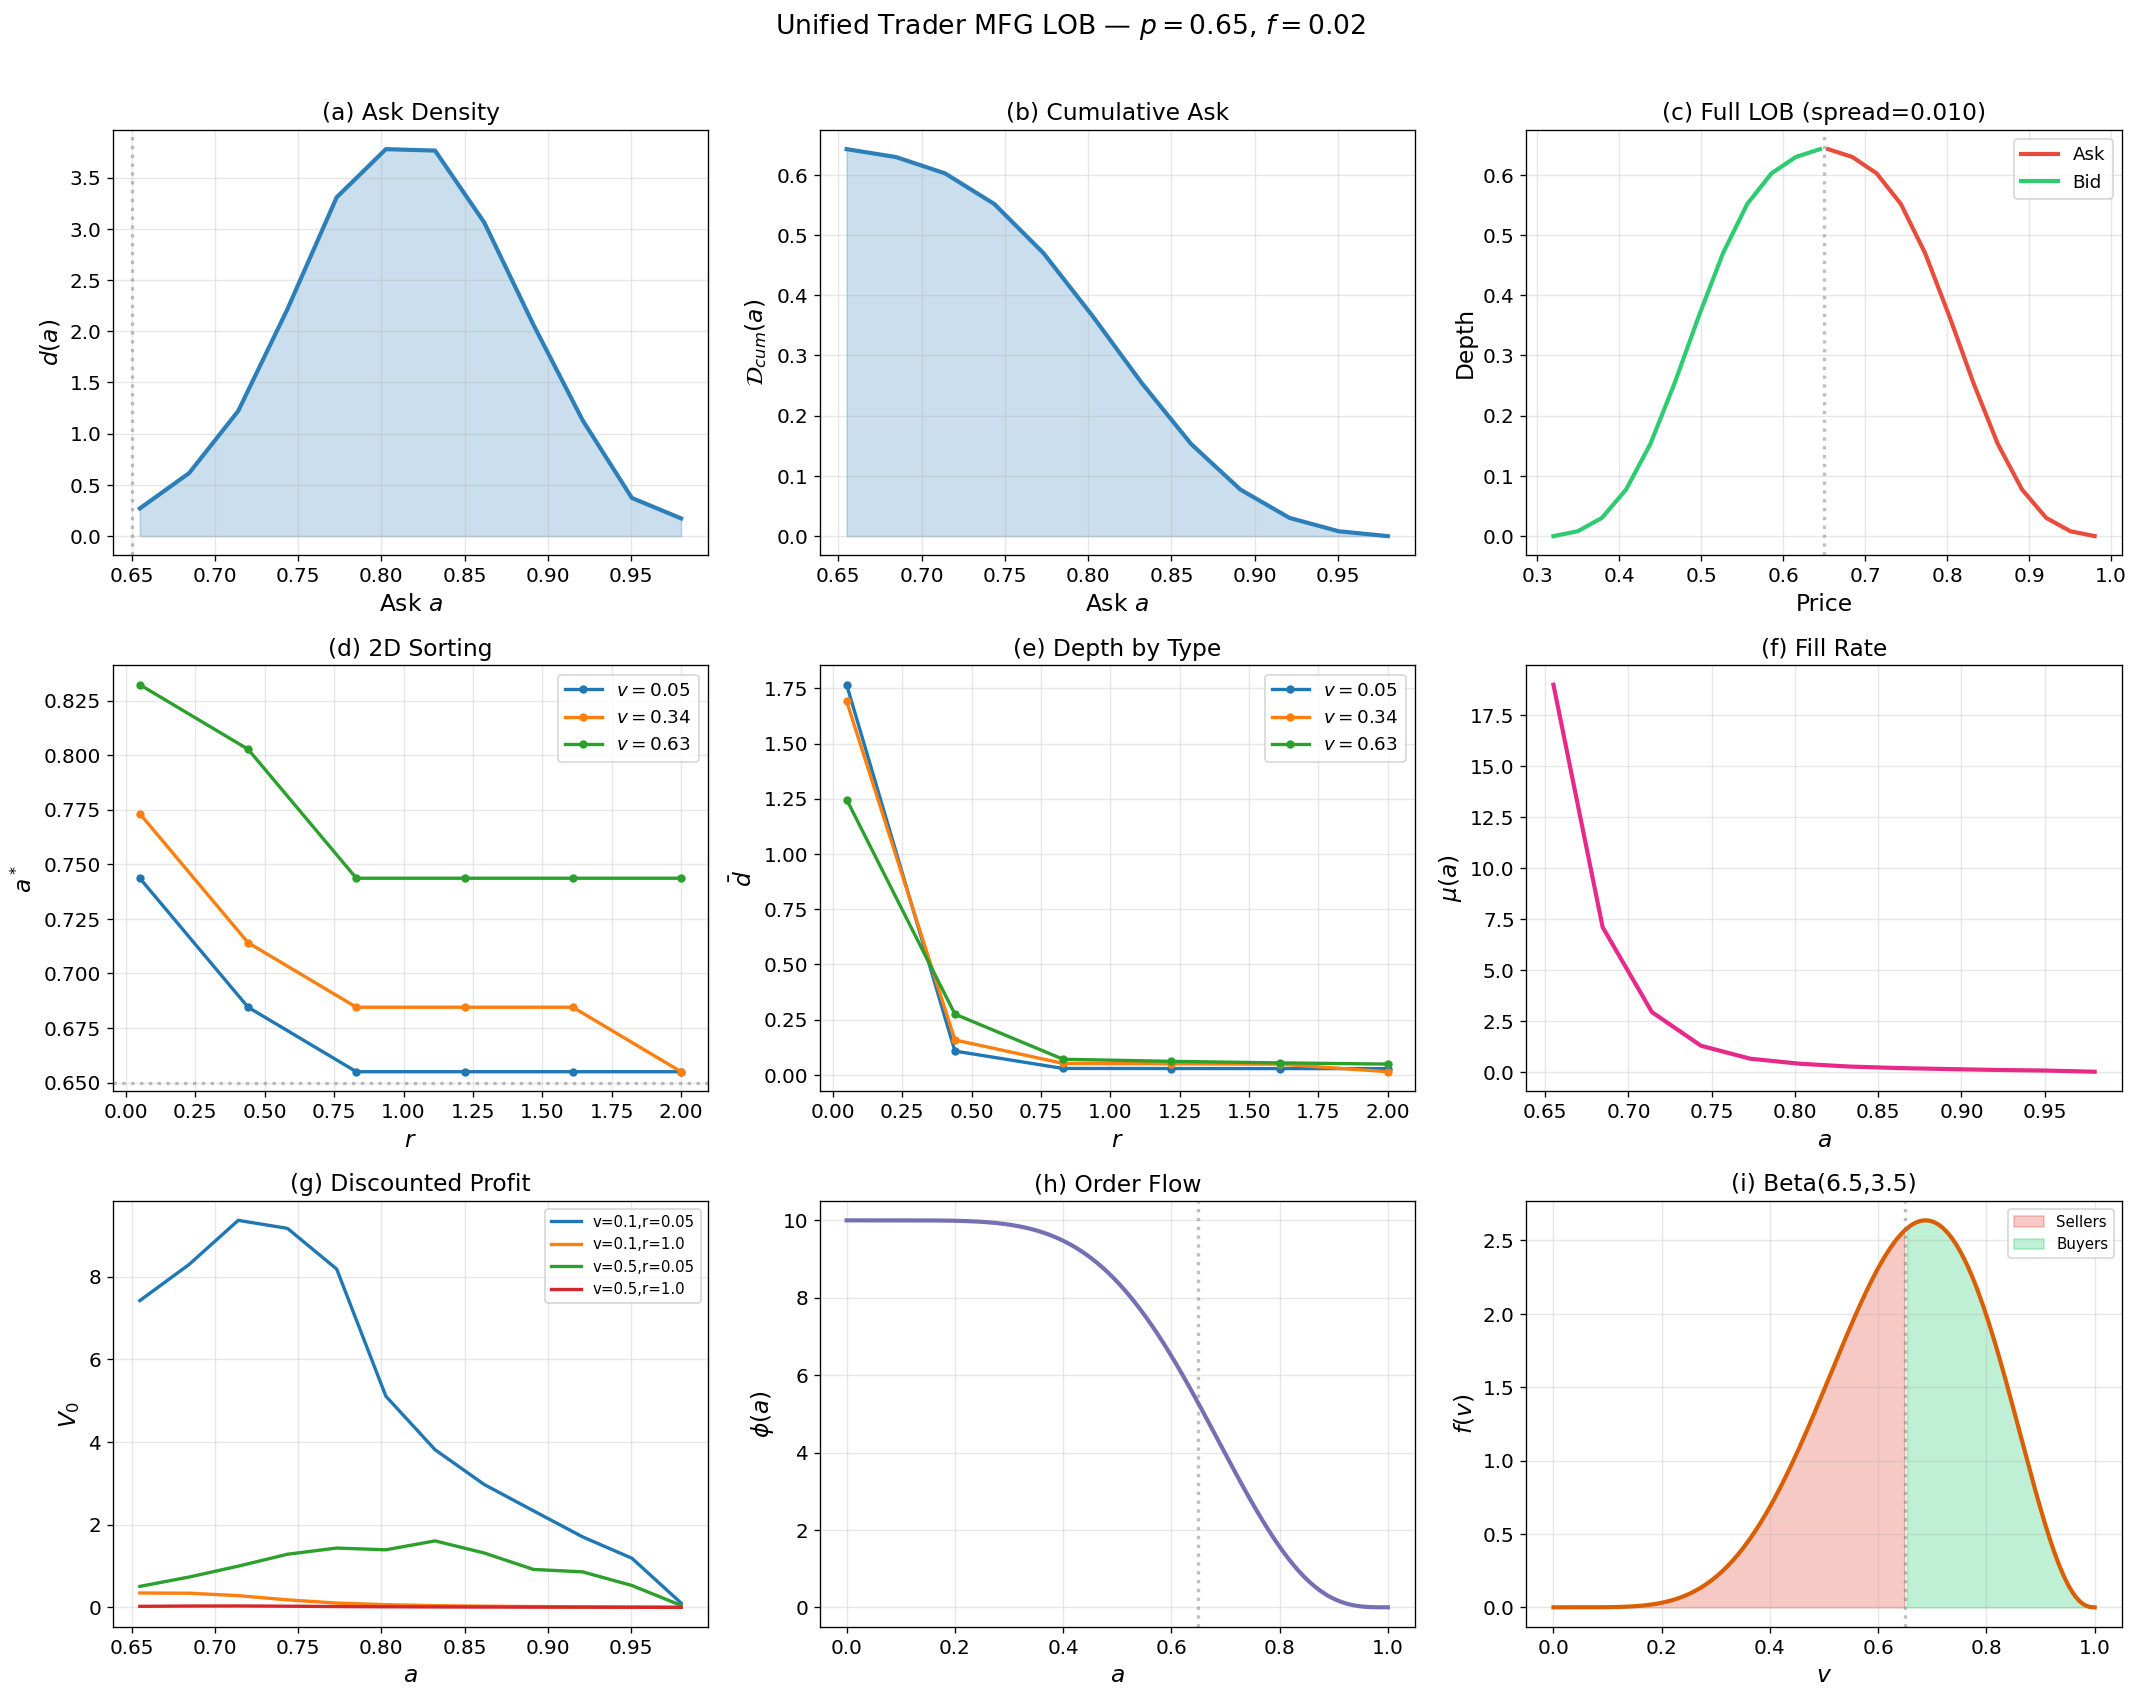

\na*(r): range [0.655, 0.832]
All asks >= p: True
D_max = 3.778 at a = 0.803


In [5]:
# Cumulative ask
D_cum=np.zeros(N_a)
for i in range(N_a):
    if len(a_grid[i:])>1: D_cum[i]=np.trapz(D_final[i:],a_grid[i:])

# Bid side: reflect through p
b_grid=2*p_mid-a_grid[::-1]; D_bid=D_final[::-1]
D_cum_bid=np.zeros(N_a)
for i in range(N_a):
    if i>0: D_cum_bid[i]=np.trapz(D_bid[:i+1],b_grid[:i+1])

spread = a_grid[0] - b_grid[-1]
print(f'Best ask={a_grid[0]:.3f}, Best bid={b_grid[-1]:.3f}, Spread={spread:.3f}')

# Value landscape
V0_land={}
for vs,rs in [(0.10,0.05),(0.10,1.0),(0.50,0.05),(0.50,1.0)]:
    if vs>=p_mid: continue
    V0a=np.full(N_a,np.nan)
    for j in range(N_a):
        if lp_margin(a_grid[j],vs)<=0.001: continue
        V0a[j],_=solve_at_price(a_grid[j],vs,rs,mu_final[j],ni=10)
    V0_land[(vs,rs)]=V0a

fig=plt.figure(figsize=(18,14))

ax=fig.add_subplot(3,3,1)
ax.plot(a_grid,D_final,color='#2c7fb8',lw=2.5)
ax.fill_between(a_grid,0,D_final,alpha=0.25,color='#2c7fb8')
ax.axvline(p_mid,color='gray',ls=':',alpha=0.5)
ax.set_xlabel('Ask $a$'); ax.set_ylabel('$d(a)$')
ax.set_title('(a) Ask Density'); ax.grid(True,alpha=0.3)

ax=fig.add_subplot(3,3,2)
ax.plot(a_grid,D_cum,color='#2c7fb8',lw=2.5)
ax.fill_between(a_grid,0,D_cum,alpha=0.25,color='#2c7fb8')
ax.set_xlabel('Ask $a$'); ax.set_ylabel(r'$\mathcal{D}_{cum}(a)$')
ax.set_title('(b) Cumulative Ask'); ax.grid(True,alpha=0.3)

ax=fig.add_subplot(3,3,3)
ax.plot(a_grid,D_cum,color='#e74c3c',lw=2.5,label='Ask')
ax.plot(b_grid,D_cum_bid,color='#2ecc71',lw=2.5,label='Bid')
ax.axvline(p_mid,color='gray',ls=':',alpha=0.5)
ax.set_xlabel('Price'); ax.set_ylabel('Depth')
ax.set_title(f'(c) Full LOB (spread={spread:.3f})'); ax.legend(); ax.grid(True,alpha=0.3)

ax=fig.add_subplot(3,3,4)
for kv in [0,N_v//2,N_v-1]:
    ax.plot(r_grid,a_star_2d[kv,:],'o-',ms=4,label=f'$v={v_grid[kv]:.2f}$')
ax.axhline(p_mid,color='gray',ls=':',alpha=0.5)
ax.set_xlabel('$r$'); ax.set_ylabel('$a^*$')
ax.set_title('(d) 2D Sorting'); ax.legend(); ax.grid(True,alpha=0.3)

ax=fig.add_subplot(3,3,5)
for kv in [0,N_v//2,N_v-1]:
    ax.plot(r_grid,d_bar_2d[kv,:],'o-',ms=4,label=f'$v={v_grid[kv]:.2f}$')
ax.set_xlabel('$r$'); ax.set_ylabel(r'$\bar{d}$')
ax.set_title('(e) Depth by Type'); ax.legend(); ax.grid(True,alpha=0.3)

ax=fig.add_subplot(3,3,6)
ax.plot(a_grid,mu_final,color='#e7298a',lw=2.5)
ax.set_xlabel('$a$'); ax.set_ylabel(r'$\mu(a)$')
ax.set_title('(f) Fill Rate'); ax.grid(True,alpha=0.3)

ax=fig.add_subplot(3,3,7)
for (vs,rs),V0a in V0_land.items():
    ax.plot(a_grid,V0a,lw=2,label=f'v={vs},r={rs}')
ax.set_xlabel('$a$'); ax.set_ylabel('$V_0$')
ax.set_title('(g) Discounted Profit'); ax.legend(fontsize=9); ax.grid(True,alpha=0.3)

ax=fig.add_subplot(3,3,8)
af=np.linspace(0,1,200)
ax.plot(af,phi_flow(af),color='#7570b3',lw=2.5)
ax.axvline(p_mid,color='gray',ls=':',alpha=0.5)
ax.set_xlabel('$a$'); ax.set_ylabel(r'$\phi(a)$')
ax.set_title('(h) Order Flow'); ax.grid(True,alpha=0.3)

ax=fig.add_subplot(3,3,9)
ax.plot(af,beta_dist.pdf(af,alpha_F,beta_F),color='#d95f02',lw=2.5)
ax.axvline(p_mid,color='gray',ls=':',alpha=0.5)
ax.fill_between(af[af<=p_mid],beta_dist.pdf(af[af<=p_mid],alpha_F,beta_F),alpha=0.3,color='#e74c3c',label='Sellers')
ax.fill_between(af[af>=p_mid],beta_dist.pdf(af[af>=p_mid],alpha_F,beta_F),alpha=0.3,color='#2ecc71',label='Buyers')
ax.set_xlabel('$v$'); ax.set_ylabel('$f(v)$')
ax.set_title(f'(i) Beta({alpha_F},{beta_F})'); ax.legend(fontsize=9); ax.grid(True,alpha=0.3)

fig.suptitle(f'Unified Trader MFG LOB — $p={p_mid}$, $f={fee}$',fontsize=16,y=1.01)
plt.tight_layout(); plt.show()

print(f'\\na*(r): range [{a_star_2d.min():.3f}, {a_star_2d.max():.3f}]')
print(f'All asks >= p: {np.all(a_star_2d >= p_mid - 0.01)}')
print(f'D_max = {D_final.max():.3f} at a = {a_grid[np.argmax(D_final)]:.3f}')

## §11. Next Steps

1. **Calibrate $F$**: fit Beta$(\alpha_F, \beta_F)$ from Polymarket order flow data
2. **Pareto $G(r)$**: replace uniform discount rates with heavy-tailed distribution
3. **Continuum limit**: replace discrete aggregation with integral equation
4. **Non-symmetric contracts**: vary $p$ across the range $[0.1, 0.99]$
5. **Price dynamics**: informational efficiency via depth-scaled impact